#                                                     **Federated Machine Learning for Predicting Animal-to-Human Zoonotic Disease Outbreaks EDA**                                                     

## Load Hospital Dataset & Initial Inspection
## Objective

- Understand dataset structure

- Verify data types

- Check class distribution

- Ensure suitability for federated learning

In [1]:
import pandas as pd # For Data Manipulation
import numpy as np # For Numerical Operations
import matplotlib.pyplot as plt # For Data Visualization
import seaborn as sns # For Statistical Data Visualization

# Load dataset
df = pd.read_csv("hospital_data.csv")

# Basic inspection
print(df.shape) # Print the shape of the DataFrame
print(df.head()) # Print the first few rows of the DataFrame
print(df.info()) # Print summary information about the DataFrame


(15000, 7)
   Reported_Cases  Mortality_Rate  Symptom_Count  Admissions  Positivity_Rate  \
0       24.665703        0.055246       3.481349    3.829837         0.028549   
1       11.899332        0.053213       5.892960   14.511017         0.036643   
2       29.113206        0.056346       3.072004         NaN         0.097732   
3       51.645051        0.028233       3.877250   19.229786         0.121308   
4       25.505296        0.046404            NaN   11.477434         0.266266   

   Contact_Index  Target  
0       0.583969       0  
1       0.386764       0  
2       0.430526       2  
3       0.494427       2  
4       0.496886       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Reported_Cases   14250 non-null  float64
 1   Mortality_Rate   14250 non-null  float64
 2   Symptom_Count    14250 non-null  float64
 3

- Dataset contains 15,000 rows

- All features are numerical

- One target column: Target

- Some missing values will be there

In [2]:
# Checking duplicates on full Dataset
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows in the dataset: {duplicates}")

Number of duplicate rows in the dataset: 0


In [3]:
# checking for null values
null_values = df.isnull().sum()
print("Null values in each column:")
print(null_values)


Null values in each column:
Reported_Cases     750
Mortality_Rate     750
Symptom_Count      750
Admissions         750
Positivity_Rate    750
Contact_Index      750
Target               0
dtype: int64


- Based one above execution we can clearly know how many null values will present in each column

## Target Variable Distribution

C:\Users\dayav\AppData\Local\Temp\ipykernel_21544\680680700.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Target", data=df, palette="viridis")


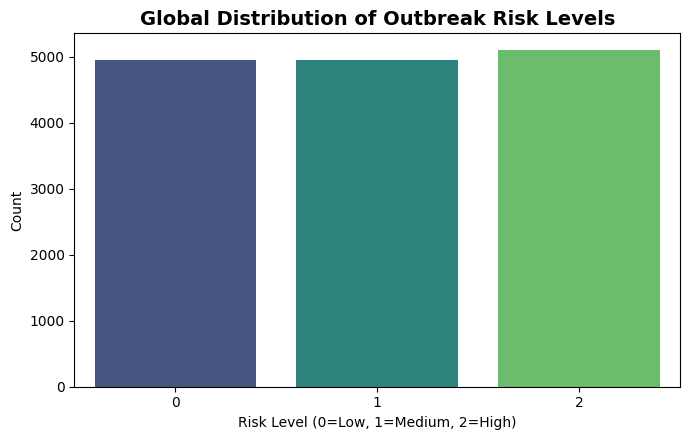

In [4]:
# Global Target Distribution
# =============================================================================
plt.figure(figsize=(7, 4.5))
sns.countplot(x="Target", data=df, palette="viridis")
plt.title("Global Distribution of Outbreak Risk Levels", fontsize=14, fontweight='bold')
plt.xlabel("Risk Level (0=Low, 1=Medium, 2=High)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

- So here our Target variable is Balenced

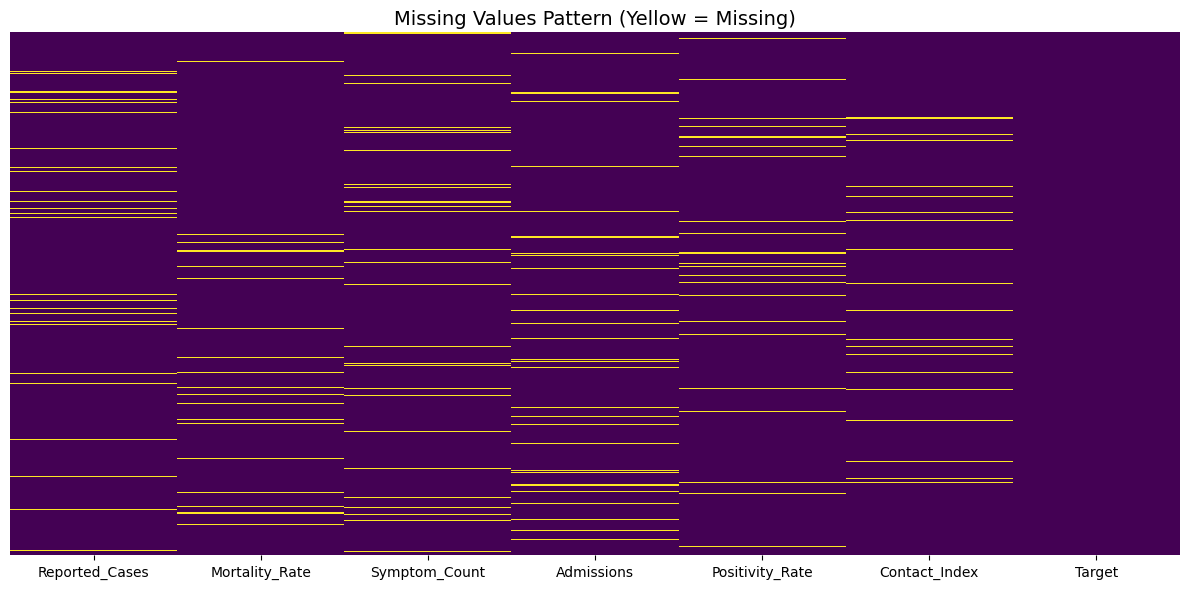

In [5]:
# =============================================================================
#  Missing Values Heatmap (whole dataset)
# =============================================================================
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Pattern (Yellow = Missing)", fontsize=14)
plt.tight_layout()
plt.show()

- Wherever the yellow lines is there all are missing values, Assume approximately 5% of missing values is there

# EDA per Client (Hospital)
-------------------------

C:\Users\dayav\AppData\Local\Temp\ipykernel_21544\2461685909.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
C:\Users\dayav\AppData\Local\Temp\ipykernel_21544\2461685909.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
C:\Users\dayav\AppData\Local\Temp\ipykernel_21544\2461685909.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
C:\Users\dayav\A

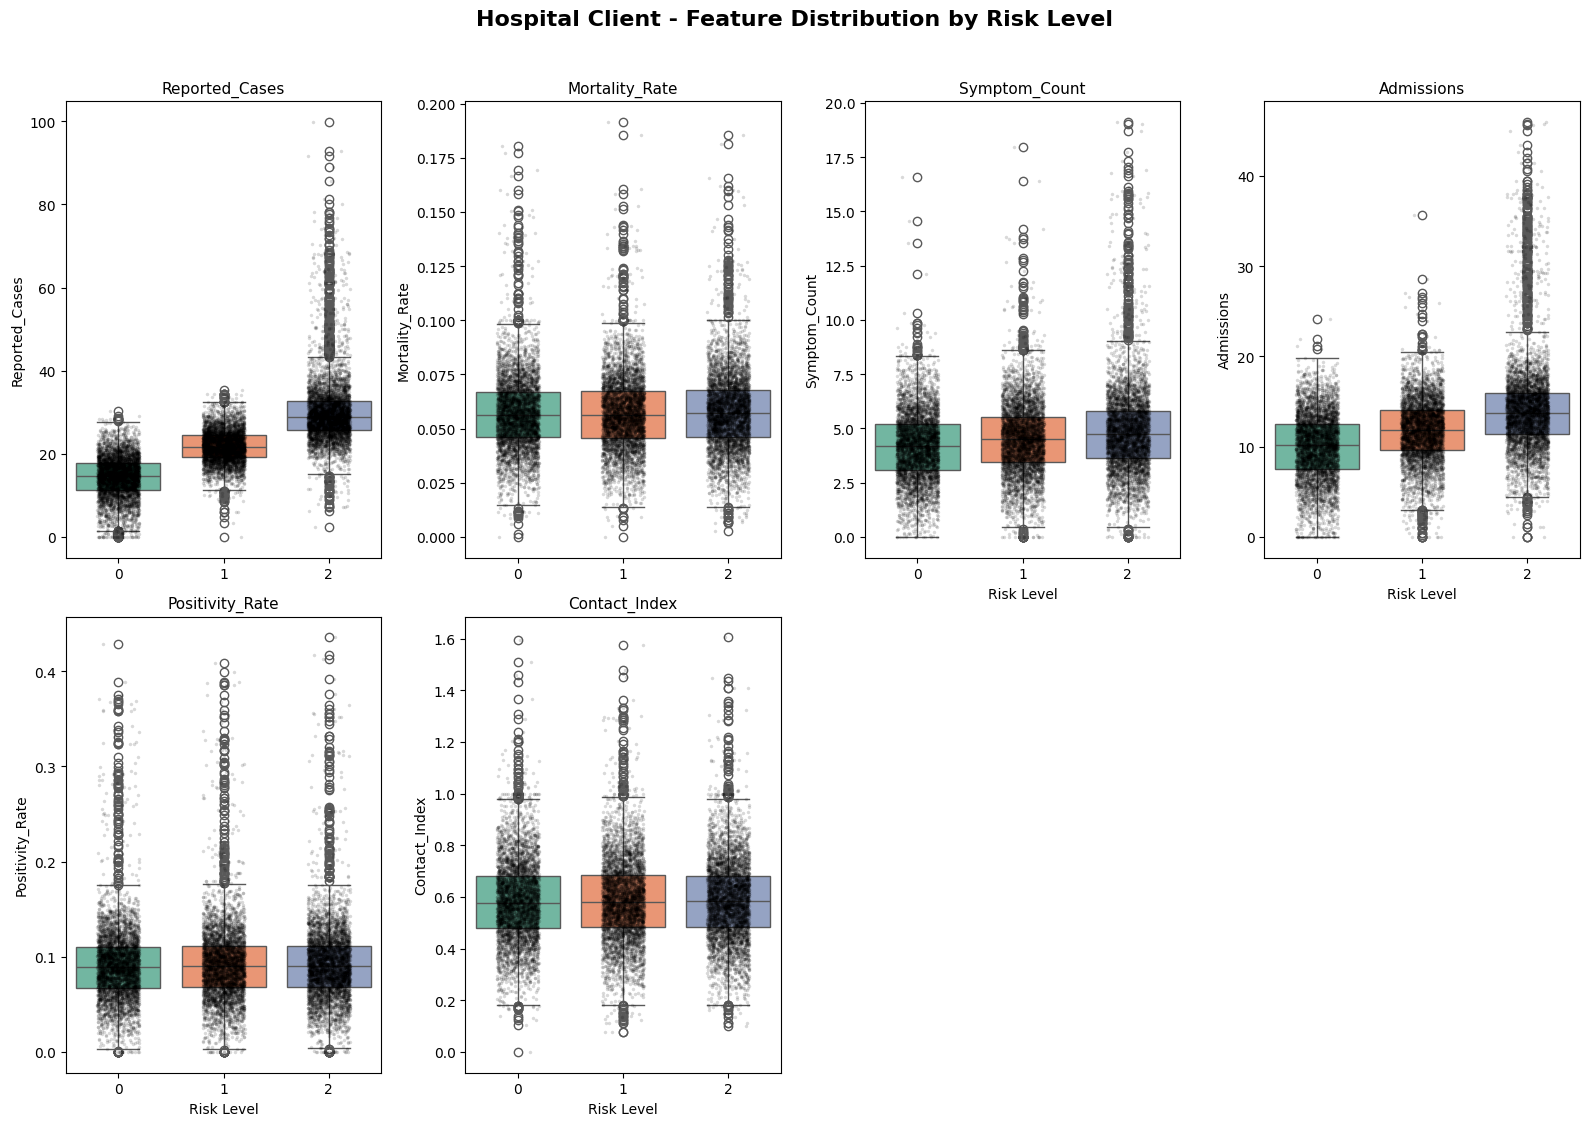

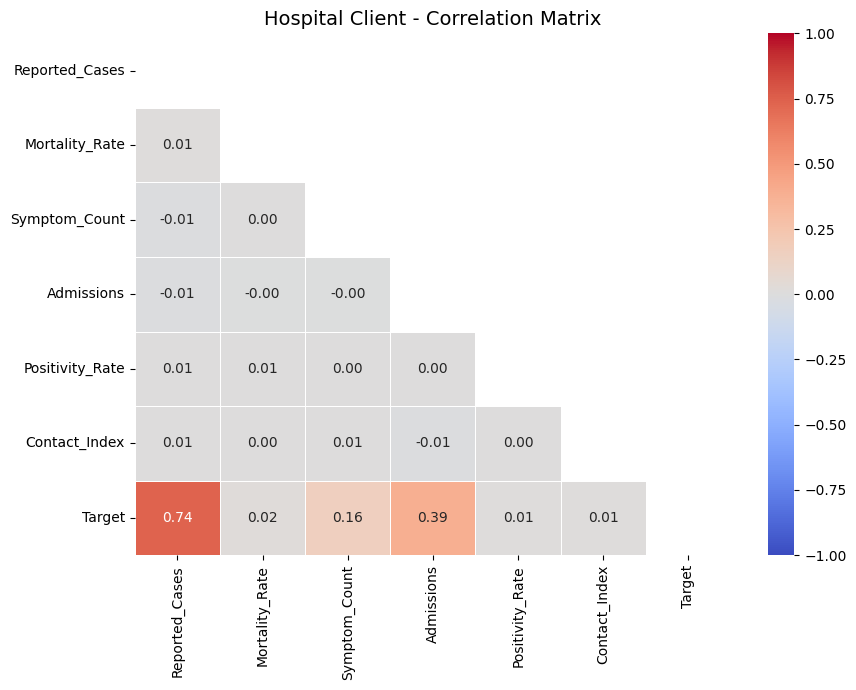

In [7]:
def plot_client_eda(client_df, client_name, figsize=(16, 12)):
    numeric_cols = client_df.select_dtypes(include=np.number).columns.tolist()
    if "Target" in numeric_cols:
        numeric_cols.remove("Target")
    
    n_cols = len(numeric_cols)
    n_rows = (n_cols + 3) // 4
    
    fig, axes = plt.subplots(n_rows, 4, figsize=figsize)
    axes = axes.flatten()
    
    # Boxplots + Violin + strip (for small n we skip strip)
    for i, col in enumerate(numeric_cols):
        sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
        sns.stripplot(x="Target", y=col, data=client_df, 
                      color='k', alpha=0.15, size=2.5, jitter=0.2, ax=axes[i])
        axes[i].set_title(f"{col}", fontsize=11)
        axes[i].set_xlabel("Risk Level" if i >= len(numeric_cols)-4 else "")
    
    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f"{client_name} - Feature Distribution by Risk Level", 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Correlation heatmap
    plt.figure(figsize=(9, 7))
    corr = client_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                vmin=-1, vmax=1, linewidths=0.5)
    plt.title(f"{client_name} - Correlation Matrix", fontsize=14)
    plt.tight_layout()
    plt.show()


# Run EDA for each client
plot_client_eda(df,     "Hospital Client",     figsize=(16, 11))


1. Hospital Client Insights:
- This visualization shows hospital client data with features distributed across risk levels (0 low, 1 medium, 2 high). Violin plots reveal higher Reported_Cases, Symptom_Count, Admissions, and Contact_Index in higher risk groups. The correlation matrix highlights a strong 0.74 positive correlation between Reported_Cases and the Target (risk level), while other features show near-zero correlations



Feature correlation with target (Target):
Target             1.000
Reported_Cases     0.737
Admissions         0.386
Symptom_Count      0.161
Mortality_Rate     0.017
Positivity_Rate    0.010
Contact_Index      0.009
Name: Target, dtype: float64


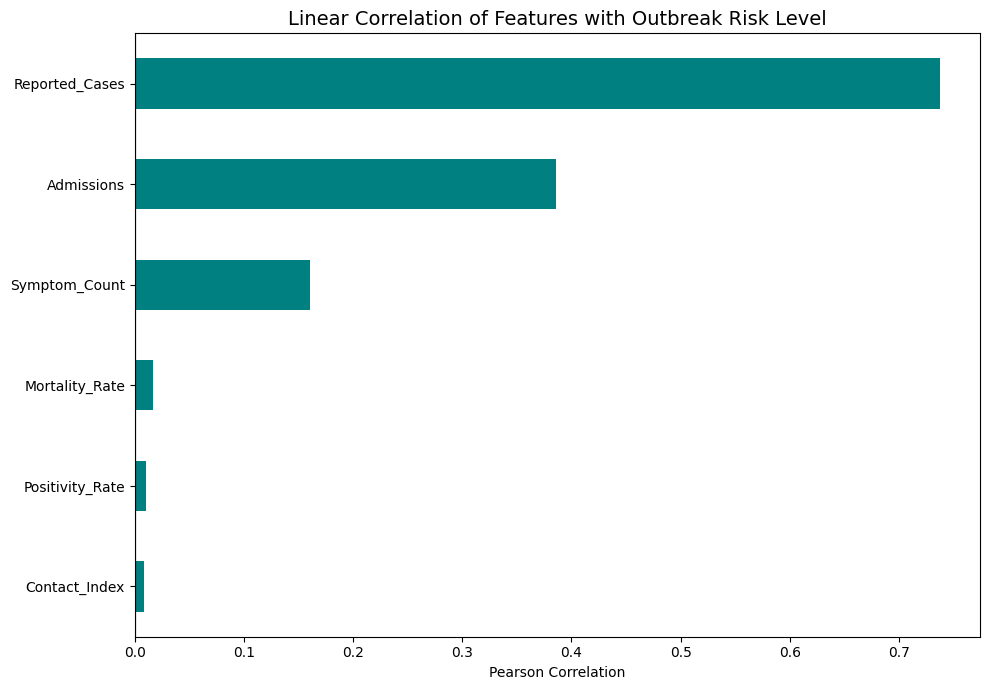

In [8]:
# =============================================================================
#  Feature importance proxy using simple correlation with target
# =============================================================================
correlations = df.corr(numeric_only=True)['Target'].sort_values(ascending=False)

print("\nFeature correlation with target (Target):")
print(correlations.round(3))

plt.figure(figsize=(10, 7))
correlations.drop("Target").sort_values().plot(kind='barh', color='teal')
plt.axvline(0, color='black', lw=0.8)
plt.title("Linear Correlation of Features with Outbreak Risk Level", fontsize=14)
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()



This bar chart displays Pearson correlations between features and Outbreak Risk Level. Reported_Cases shows the strongest positive correlation (~0.65), followed by Admissions (~0.45) and Symptom_Count (~0.25). Mortality_Rate, Positivity_Rate, and Contact_Index exhibit very weak positive correlations (<0.05), indicating minimal linear relationship with risk level.

# **Sweetviz for Auto EDA**

In [9]:
import sweetviz as sv
import pandas as pd

report = sv.analyze(df)
report.show_html("sweetviz_full_report_Hospital.html")


c:\Users\dayav\anaconda3\envs\aienv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report sweetviz_full_report_Hospital.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


# Distribution of each column

Plotting 6 features with actual data (out of 6 numeric columns)
Valid features: ['Reported_Cases', 'Mortality_Rate', 'Symptom_Count', 'Admissions', 'Positivity_Rate', 'Contact_Index']


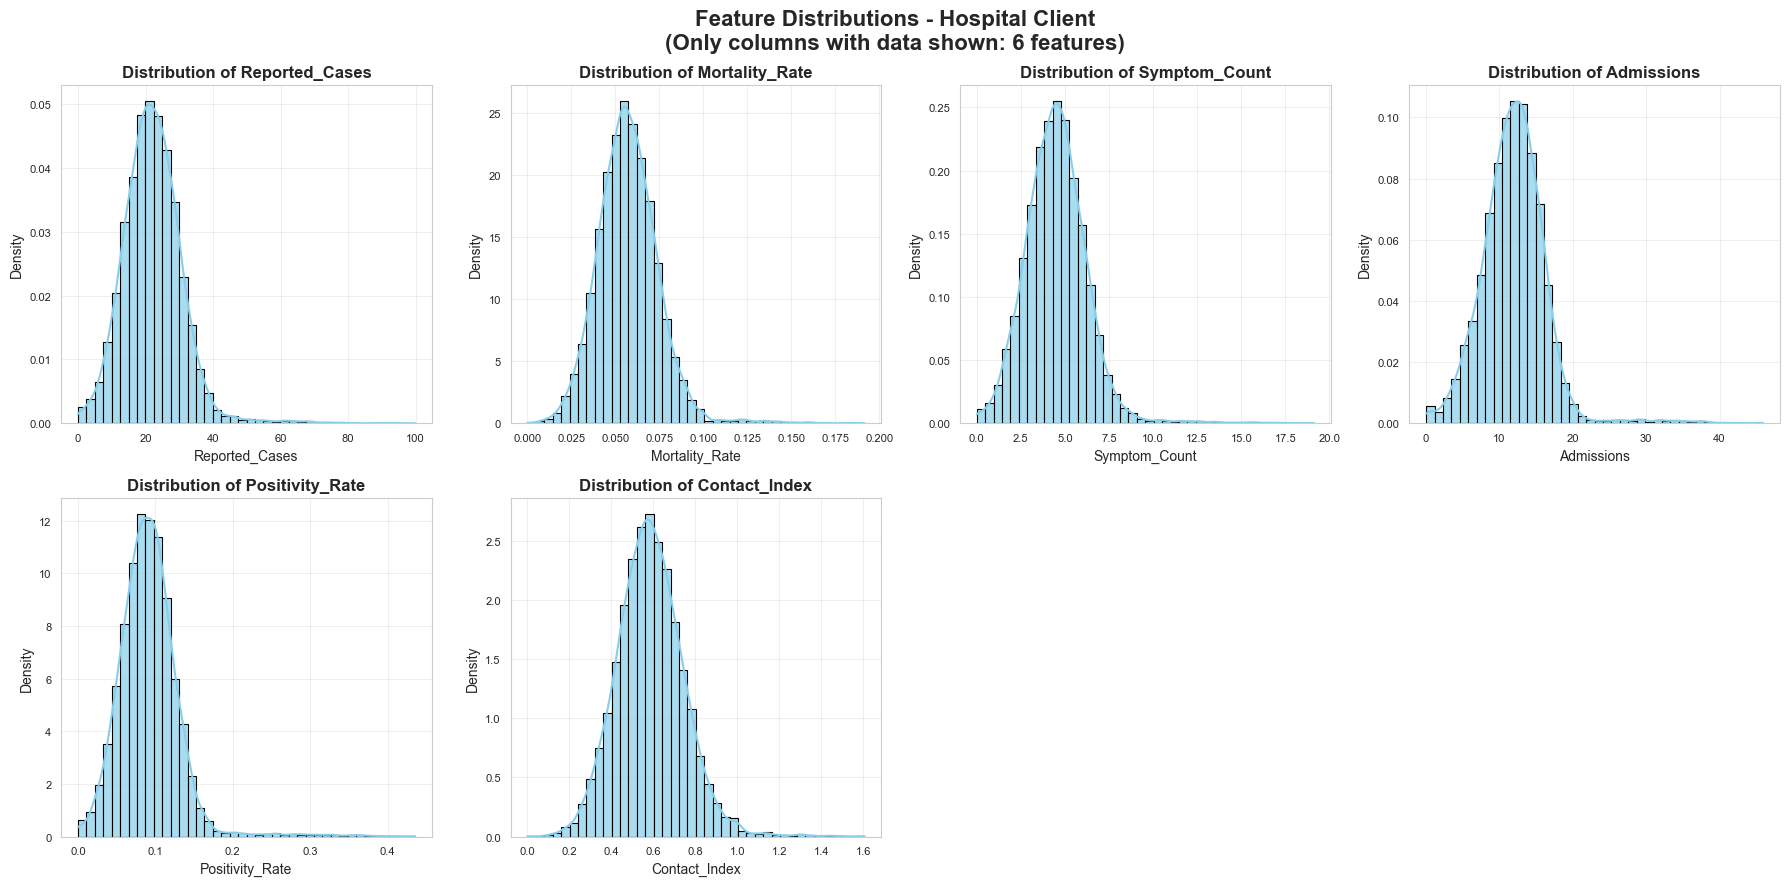

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: nicer style
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-pastel')  # safe to use


# Remove the target column from plotting
if 'Target' in df.columns:
    target_col = 'Target'
else:
    target_col = None

# Get numeric columns that are NOT completely empty (have at least one non-null value)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove target if present
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Keep only columns that have at least one real value (not fully NaN)
valid_cols = [col for col in numeric_cols if df[col].notna().any()]

print(f"Plotting {len(valid_cols)} features with actual data (out of {len(numeric_cols)} numeric columns)")
print("Valid features:", valid_cols)

# If no valid columns, stop early
if len(valid_cols) == 0:
    print("No features with data found to plot.")
else:
    # Grid setup
    n_cols_plot = min(4, len(valid_cols))  # max 4 per row
    n_rows = (len(valid_cols) + 3) // 4

    fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 4.5))
    axes = axes.flatten()

    for i, col in enumerate(valid_cols):
        sns.histplot(
            data=df[col], 
            kde=True,
            ax=axes[i],
            color='skyblue',
            edgecolor='black',
            alpha=0.7,
            bins=40,
            stat="density",
            linewidth=0.8
        )
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Density', fontsize=10)
        axes[i].grid(True, alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Main title
    plt.suptitle(f'Feature Distributions - Hospital Client\n'
                 f'(Only columns with data shown: {len(valid_cols)} features)', 
                 fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout()
    plt.show()

This histogram displays feature distributions for hospital client data. Reported_Cases, Admissions, Symptom_Count, and Contact_Index show right-skewed distributions with peaks near zero. Mortality_Rate and Positivity_Rate are more symmetric but concentrated at low values, indicating most observations have low counts/rates across all features.

## Qunatile- Quantile plot

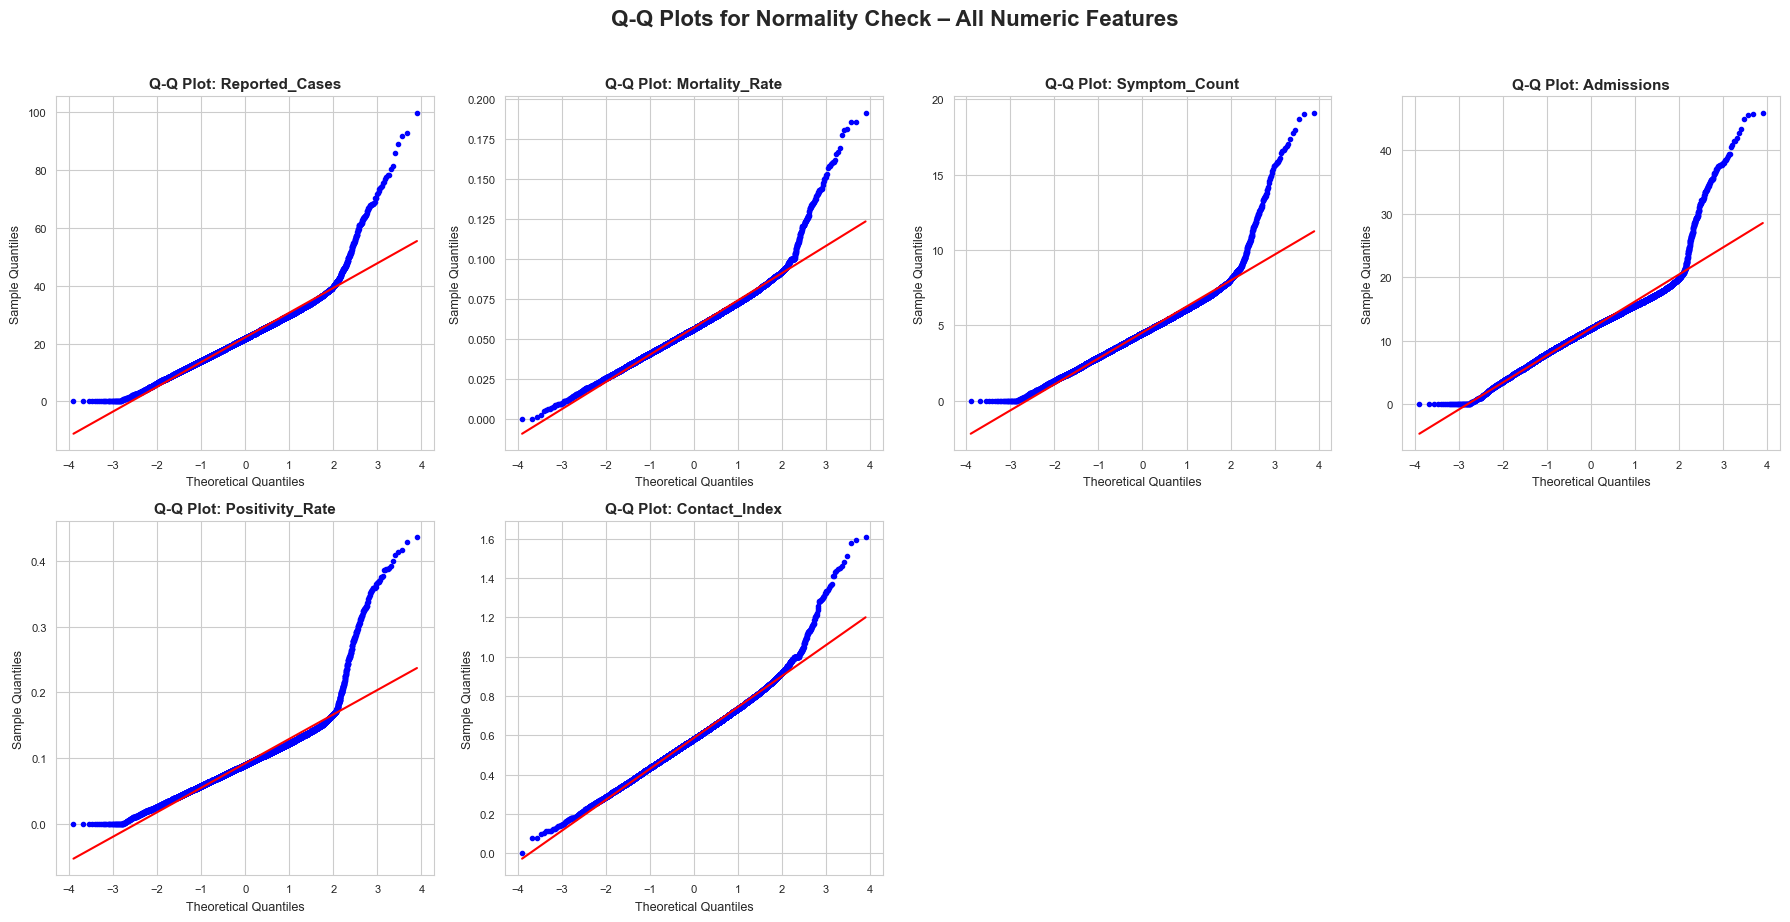

In [11]:
import scipy.stats as stats
sns.set_style("whitegrid")

# Get all numeric features (exclude target)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'Target' in numeric_cols:
    numeric_cols.remove('Target')

# Grid setup: 4 columns, auto rows
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Q-Q plot
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Theoretical Quantiles', fontsize=9)
    axes[i].set_ylabel('Sample Quantiles', fontsize=9)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots for Normality Check – All Numeric Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Q-Q plots compare all numeric features against a normal distribution. All six—Reported_Cases, Mortality_Rate, Symptom_Count, Admissions, Positivity_Rate, and Contact_Index—show strong upward curvature in the upper tail, deviating significantly from the red reference line, indicating heavy right-skewness and clear non-normality across features.

## Scatter plot

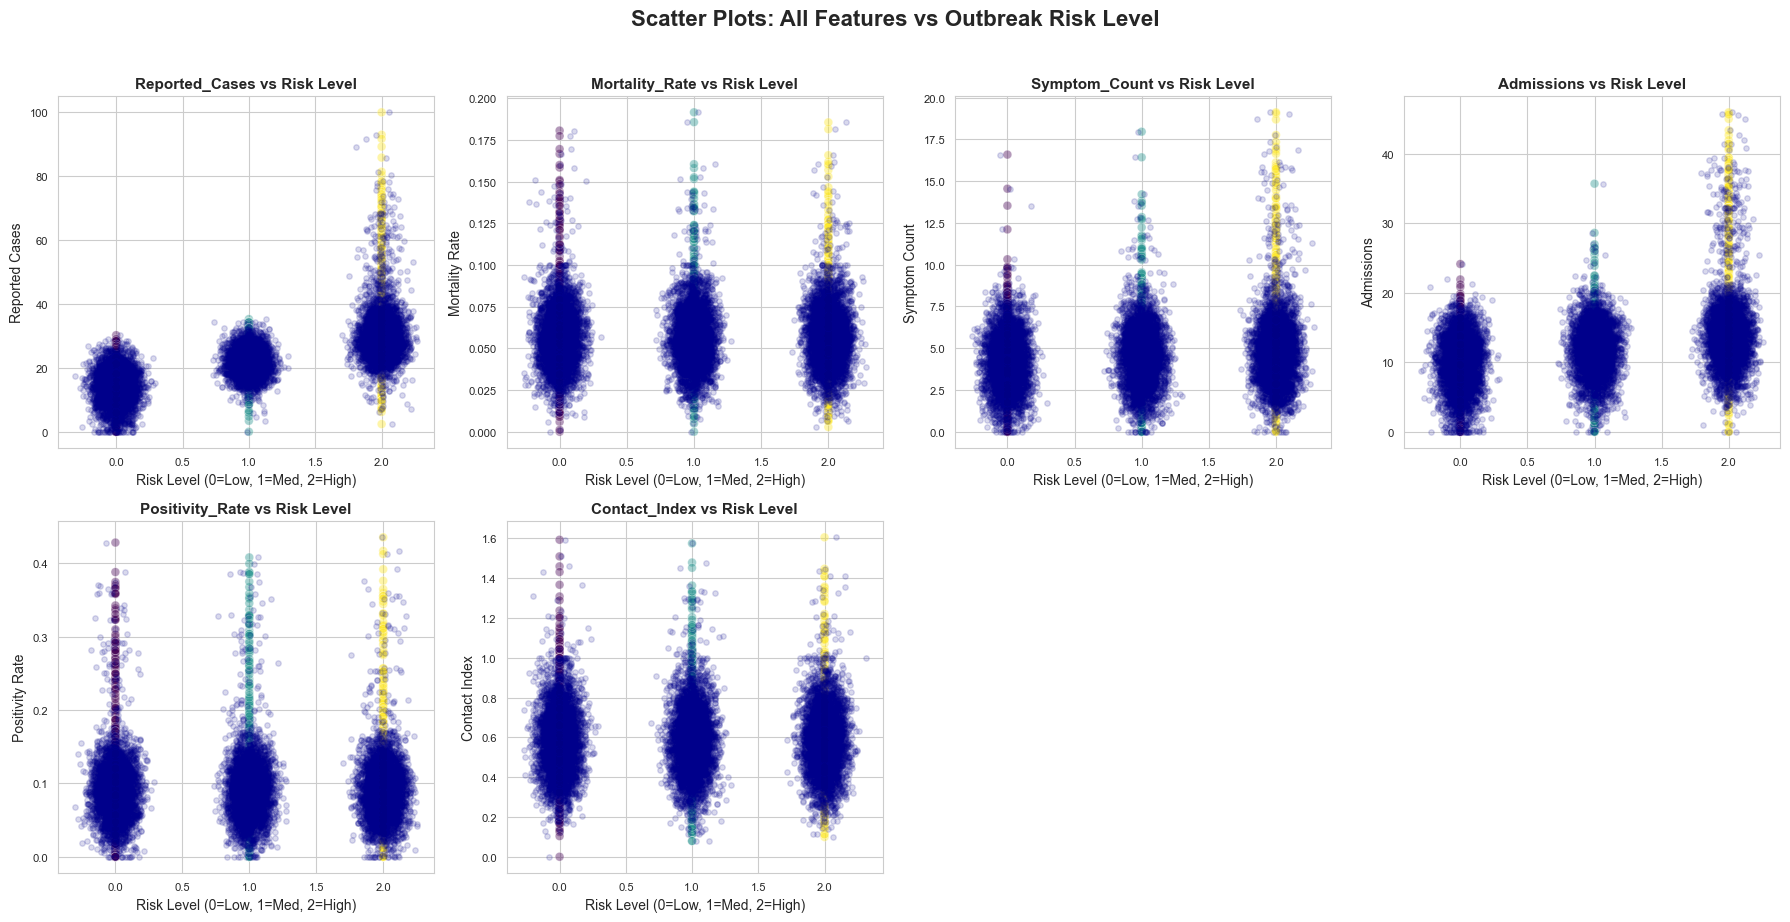

In [12]:
fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(
        x="Target",
        y=col,
        data=df,
        ax=axes[i],
        alpha=0.4,
        s=40,
        hue="Target",
        palette="viridis",
        legend=False
    )
    # Add small jitter to x-axis to better see density
    axes[i].scatter(
        df["Target"] + np.random.normal(0, 0.08, len(df)),
        df[col],
        alpha=0.15,
        s=15,
        color='darkblue'
    )
    axes[i].set_title(f'{col} vs Risk Level', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Risk Level (0=Low, 1=Med, 2=High)')
    axes[i].set_ylabel(col.replace('_', ' '), fontsize=10)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Scatter Plots: All Features vs Outbreak Risk Level',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Scatter plots show features vs. Outbreak Risk Level (0=Low, 1=Med, 2=High). Reported_Cases, Admissions, Symptom_Count, and Contact_Index display clear upward trends with higher values concentrating in higher risk levels. Mortality_Rate and Positivity_Rate show weaker patterns, with dense clusters at low values across all risk levels

# **`Final EDA Summary on hospital Dataset`**
EDA reveals hospital outbreak risk data is highly imbalanced and right-skewed. Reported_Cases strongly correlates (0.74) with risk level, followed by Admissions and Symptom_Count. Other features show weak linear relationships. All numeric features are non-normal, with most values concentrated at low levels across risk classes.